# Email spam classification with GPT and BERT

## 1. Download data
Download data from kaggle, and then unzip it.

The folder structure is for google colab, modify it if needed.

In [ ]:
!curl -L -o /content/emails-for-spam-or-ham-classification-trec-2007.zip\
  https://www.kaggle.com/api/v1/datasets/download/bayes2003/emails-for-spam-or-ham-classification-trec-2007

!unzip /content/emails-for-spam-or-ham-classification-trec-2007.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  482M  100  482M    0     0  65.9M      0  0:00:07  0:00:07 --:--:-- 84.6M
Archive:  /content/emails-for-spam-or-ham-classification-trec-2007.zip
  inflating: email_origin.csv        
  inflating: email_text.csv          
  inflating: trec07p.tgz             


## 2.Install libs

In [ ]:
!pip install torch
!pip install scikit-learn
!pip install nltk
!pip install sentence-transformers
!pip install torchviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 51.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

## 3. Import libs

In [ ]:
import os
import glob
import re
import pandas as pd
import re
import string
import numpy as np

import nltk
import torch
import torch.nn as nn
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import TensorDataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from transformers import BertModel, BertTokenizer
from transformers import GPT2Tokenizer, GPT2Model

from sentence_transformers import SentenceTransformer


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from torch.optim.lr_scheduler import StepLR

import matplotlib.pyplot as plt

## 4. Download common words

In [ ]:
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## 5. Read email dataset

In [ ]:
df = pd.read_csv(r'email_text.csv')
df.head()

,label,text
0,1,do you feel the pressure to perform and not ri...
1,0,hi i've just updated from the gulus and i chec...
2,1,mega authenticv i a g r a discount pricec i a ...
3,1,hey billy it was really fun going out the othe...
4,1,system of the home it will have the capabiliti...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53668 entries, 0 to 53667
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   53668 non-null  int64 
 1   text    53668 non-null  object
dtypes: int64(1), object(1)
memory usage: 838.7+ KB


## 6. Show percentage of ham and spam

In [ ]:
df.label.value_counts(normalize=True)

,proportion
label,
1,0.557558
0,0.442442


In [ ]:
df.label.value_counts()

,count
label,
1,29923
0,23745


## 6. Define cleaner function

In [ ]:
def text_cleaner(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)

    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'m", " am", text)

    text = re.sub(r'[^\w\s]', '', text)

    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text)
    filtered_text = [word for word in tokens if word.lower() not in stop_words]

    lemmatizer = WordNetLemmatizer()
    lemmatized_text = [lemmatizer.lemmatize(word) for word in filtered_text]

    cleaned_text = ' '.join(lemmatized_text)

    return cleaned_text

In [ ]:
df['cleaned_text'] = df['text'].apply(text_cleaner)
df.head()

,label,text,cleaned_text
0,1,do you feel the pressure to perform and not ri...,feel pressure perform rising occasion try v ia...
1,0,hi i've just updated from the gulus and i chec...,hi updated gulu check mirror seems little typo...
2,1,mega authenticv i a g r a discount pricec i a ...,mega authenticv g r discount pricec l discount...
3,1,hey billy it was really fun going out the othe...,hey billy really fun going night talking said ...
4,1,system of the home it will have the capabiliti...,system home capability linked far know within ...


## 7. Base model to compare(BERT)

In [ ]:
model_name = 'sentence-transformers/bert-base-nli-mean-tokens'
tokenizer = BertTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/399 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

In [ ]:
model = SentenceTransformer(model_name)
embeddings = model.encode(df['cleaned_text'].tolist())
target = df['label']

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.77k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### 7.1. set up train and test datasets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(embeddings, target, test_size=0.2, random_state=42)

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

### 7.2 Define SpamClassifier class

In [ ]:
class SpamClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_prob=0.2):
        super(SpamClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

### 7.3. Define model parameters

In [ ]:
input_size = embeddings.shape[1]
hidden_size = 256
output_size = 1

In [ ]:
model = SpamClassifier(input_size, hidden_size, output_size)

In [ ]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters())

### 7.4. Training

In [ ]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

epoch_num = 10

for epoch in range(epoch_num):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for inputs, labels in train_loader:
        labels = labels.unsqueeze(1).float()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        predicted_train = (outputs > 0.5).float()
        correct_train += (predicted_train == labels).sum().item()
        total_train += labels.size(0)

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            labels = labels.unsqueeze(1).float()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            predicted_test = (outputs > 0.5).float()
            correct_test += (predicted_test == labels).sum().item()
            total_test += labels.size(0)

    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(correct_test / total_test)

    print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Test Loss: {test_losses[-1]}, Test Accuracy: {test_accuracies[-1]}")

Epoch 1, Train Loss: 0.14148094986174006, Train Accuracy: 0.9467089020356827, Test Loss: 0.10415615308808074, Test Accuracy: 0.9661822247065399
Epoch 2, Train Loss: 0.09497856200171632, Train Accuracy: 0.966273815623981, Test Loss: 0.08622618958040784, Test Accuracy: 0.970840320476989
Epoch 3, Train Loss: 0.07969789642940557, Train Accuracy: 0.9724227884660176, Test Loss: 0.0816675850288621, Test Accuracy: 0.9743804732625303
Epoch 4, Train Loss: 0.07109615131612346, Train Accuracy: 0.9755438580146271, Test Loss: 0.0817436078664503, Test Accuracy: 0.9728898826159866
Epoch 5, Train Loss: 0.06308897433172003, Train Accuracy: 0.9776400987562305, Test Loss: 0.06867477726128916, Test Accuracy: 0.9773616545556176
Epoch 6, Train Loss: 0.05987170869764739, Train Accuracy: 0.9796198816788559, Test Loss: 0.07036814723098705, Test Accuracy: 0.9783864356251164
Epoch 7, Train Loss: 0.05279445117410625, Train Accuracy: 0.9814133320911166, Test Loss: 0.07079149790929694, Test Accuracy: 0.9777343022172

### 7.5. Plot Losses and Accuracies

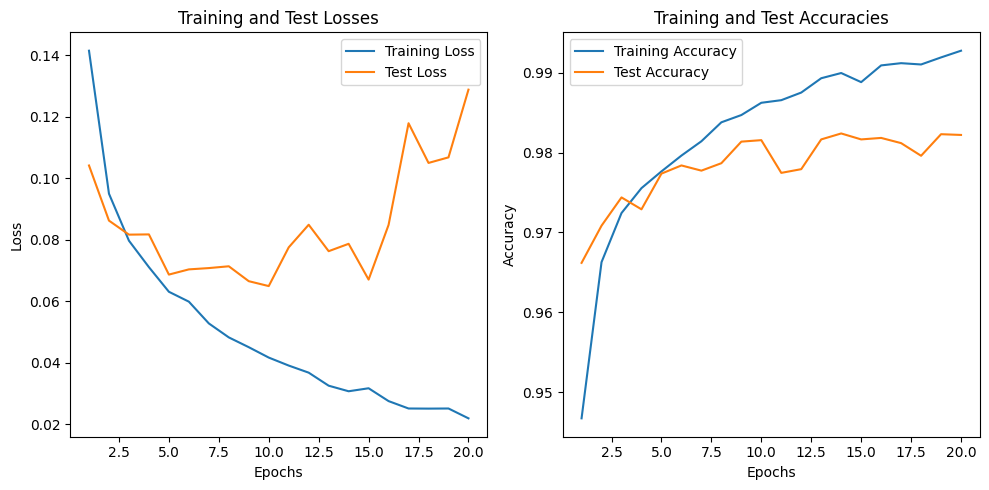

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epoch_num + 1), train_losses, label='Training Loss')
plt.plot(range(1, epoch_num + 1), test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Losses')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1,epoch_num + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, epoch_num + 1), test_accuracies, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracies')
plt.legend()

plt.tight_layout()
plt.show()

### 7.6. Print F1 and Accuracy

In [ ]:
probabilities = model(X_test_tensor)
predictions = probabilities.detach().numpy()

In [ ]:
threshold = 0.5
predicted_labels = (predictions > threshold).astype(int)

y_true = y_test_tensor.detach().numpy().astype(int)

f1_weighted = f1_score(y_true, predicted_labels, average='weighted')
accuracy = accuracy_score(y_true, predicted_labels)
precision = precision_score(y_true, predicted_labels)
recall = recall_score(y_true, predicted_labels)

print("F1-score:", f1_weighted)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

F1-score: 0.9821884420934931
Accuracy: 0.9822060741568847
Precision: 0.9768365320979484
Recall: 0.9914357682619648


## 8 Setup GPT version

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### 8.1 Setup model

In [ ]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token
model = GPT2Model.from_pretrained('gpt2')
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
model.to(device)

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)

### 8.2 Tokenizer input

In [ ]:
encoded_captions = tokenizer(
    df['cleaned_text'].tolist(),
    return_tensors='pt',
    padding=True,
    truncation=True)

encoded_captions = {key: value.to(device) for key, value in encoded_captions.items()}

In [ ]:
input_ids = encoded_captions['input_ids']

In [ ]:
batch_size = 4
all_sentence_embeddings = []

for i in range(0, len(encoded_captions['input_ids']), batch_size):
    batch_input_ids = encoded_captions['input_ids'][i:i+batch_size].to(device)
    batch_attention_mask = encoded_captions['attention_mask'][i:i+batch_size].to(device)

    with torch.no_grad():
        batch_outputs = model(batch_input_ids)

    word_embeddings = batch_outputs.last_hidden_state

    masked_word_embeddings = word_embeddings * batch_attention_mask.unsqueeze(-1).float()

    sentence_embeddings = masked_word_embeddings.sum(dim=1)

    sentence_embeddings /= batch_attention_mask.sum(dim=1, keepdim=True).float()

    all_sentence_embeddings.append(sentence_embeddings)

all_sentence_embeddings = torch.cat(all_sentence_embeddings, dim=0)

### 8.3 Get target value

In [ ]:
target = df['label']

### 8.4 Setup training and test datasets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(all_sentence_embeddings, target, test_size=0.2, random_state=42)

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

<ipython-input-90-e0327f52ab0d>:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
<ipython-input-90-e0327f52ab0d>:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32)


### 8.5 Setup spam classifier for GPT

In [ ]:
class SpamClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_prob=0.2):
        super(SpamClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

### 8.6 Setup model

In [ ]:
input_size = sentence_embeddings.shape[1]
hidden_size = 256
output_size = 1

In [ ]:
model_elmo = SpamClassifier(input_size, hidden_size, output_size)

In [ ]:
model_elmo = model_elmo.to(device)

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_elmo.parameters())

### 8.7 Train

In [ ]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

epoch_num = 20

for epoch in range(epoch_num):
    model_elmo.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        inputs = inputs.to(device)
        labels = labels.to(device).float()
        outputs = model_elmo(inputs)
        loss = criterion(outputs.squeeze(1), labels)
        loss.backward()
        optimizer.step()
        if torch.isnan(loss):
           pass
        else:
          running_loss += loss.item()

        predicted_train = torch.tensor([0 if i < 0.5 else 1 for i in outputs.squeeze(1)])
        predicted_train = predicted_train.to(device)
        total_train += labels.size(0)
        correct_train += (predicted_train == labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    model_elmo.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model_elmo(inputs)
            loss = criterion(outputs.squeeze(1), labels)

            if torch.isnan(loss):
                pass
            else:
              test_loss += loss.item()

            predicted_test = torch.tensor([0 if i < 0.5 else 1 for i in outputs.squeeze(1)])
            predicted_test = predicted_test.to(device)
            total_test += labels.size(0)
            correct_test += (predicted_test == labels).sum().item()


    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(correct_test / total_test)

    print(f"Epoch {epoch+1}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Test Loss: {test_losses[-1]}, Test Accuracy: {test_accuracies[-1]}")

Epoch 1, Train Loss: 0.033634034336590374, Train Accuracy: 0.5745562957096939, Test Loss: 0.0, Test Accuracy: 0.5547792062604807
Epoch 2, Train Loss: 0.0, Train Accuracy: 0.5582522010527787, Test Loss: 0.0, Test Accuracy: 0.5547792062604807
Epoch 3, Train Loss: 0.0, Train Accuracy: 0.5582522010527787, Test Loss: 0.0, Test Accuracy: 0.5547792062604807
Epoch 4, Train Loss: 0.0, Train Accuracy: 0.5582522010527787, Test Loss: 0.0, Test Accuracy: 0.5547792062604807
Epoch 5, Train Loss: 0.0, Train Accuracy: 0.5582522010527787, Test Loss: 0.0, Test Accuracy: 0.5547792062604807
Epoch 6, Train Loss: 0.0, Train Accuracy: 0.5582522010527787, Test Loss: 0.0, Test Accuracy: 0.5547792062604807
Epoch 7, Train Loss: 0.0, Train Accuracy: 0.5582522010527787, Test Loss: 0.0, Test Accuracy: 0.5547792062604807
Epoch 8, Train Loss: 0.0, Train Accuracy: 0.5582522010527787, Test Loss: 0.0, Test Accuracy: 0.5547792062604807
Epoch 9, Train Loss: 0.0, Train Accuracy: 0.5582522010527787, Test Loss: 0.0, Test Accu

### 8.8 Plot data

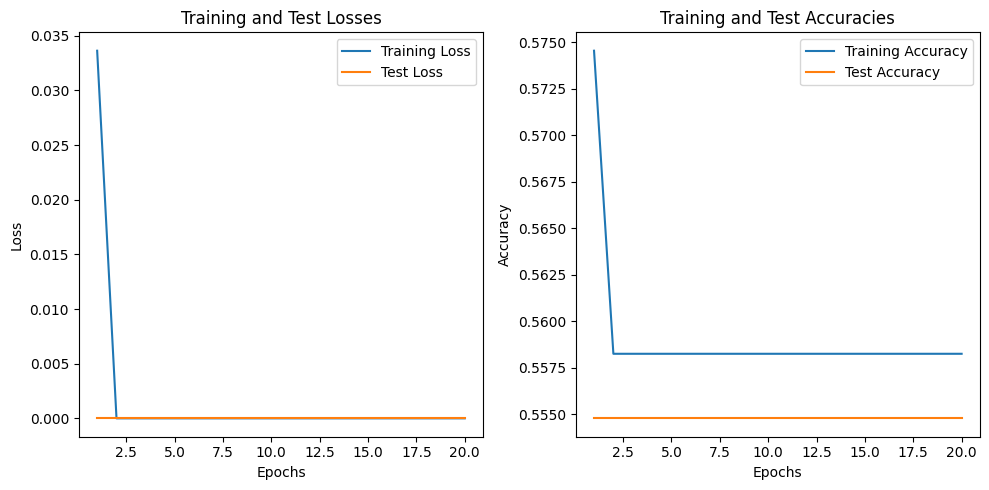

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, epoch_num+1), train_losses, label='Training Loss')
plt.plot(range(1, epoch_num+1), test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Losses')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epoch_num+1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, epoch_num+1), test_accuracies, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracies')
plt.legend()

plt.tight_layout()
plt.show()

### 8.9 Print result

In [ ]:
probabilities = model_elmo(X_test_tensor)
predictions = probabilities.detach().cpu().numpy()

In [ ]:
threshold = 0.5
predicted_labels = (predictions > threshold).astype(int)

y_true = y_test_tensor.detach().numpy().astype(int)

f1_weighted = f1_score(y_true, predicted_labels, average='weighted')
accuracy = accuracy_score(y_true, predicted_labels)
precision = precision_score(y_true, predicted_labels)
recall = recall_score(y_true, predicted_labels)

print("F1-score:", f1_weighted)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

F1-score: 0.2743131790474006
Accuracy: 0.4452207937395193
Precision: 0.0
Recall: 0.0


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
